Best Parameters: {'svm__C': 0.1, 'svm__degree': 2, 'svm__gamma': 'scale', 'svm__kernel': 'linear'}
Best CV Accuracy: 0.975

Test Accuracy: 0.9333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



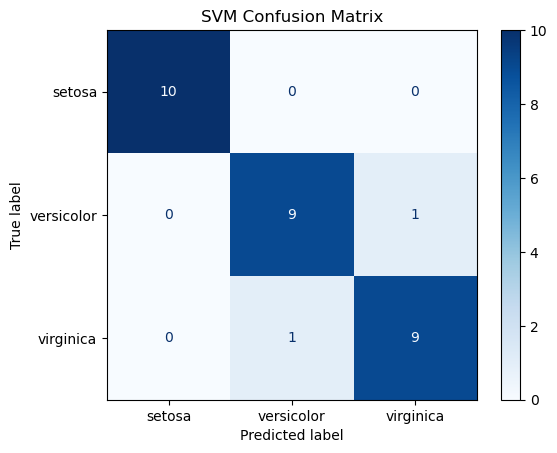

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Support Vector Machine (SVM) - complete example (classification)

# 1) Imports
import matplotlib.pyplot as plt


# 2) Load sample dataset
data = load_iris()
X = data.data
y = data.target
target_names = data.target_names

# 3) Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Build pipeline:
#    - StandardScaler: scales features (important for SVM)
#    - SVC: Support Vector Classifier
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC())
])

# 5) Hyperparameter grid
param_grid = {
    "svm__kernel": ["linear", "rbf", "poly"],
    "svm__C": [0.1, 1, 10, 100],
    "svm__gamma": ["scale", "auto"],
    "svm__degree": [2, 3]  # used only when kernel='poly'
}

# 6) Grid search with cross-validation
grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

# 7) Train
grid.fit(X_train, y_train)

# 8) Best model and parameters
best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", round(grid.best_score_, 4))

# 9) Evaluate on test set
y_pred = best_model.predict(X_test)
print("\nTest Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=target_names))

# 10) Confusion matrix plot
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(cmap="Blues")
plt.title("SVM Confusion Matrix")
plt.show()